In [1]:
import gc
import os
os.environ['NUMBA_NUM_THREADS'] = '32'
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numba import get_num_threads, set_num_threads

from core import (
    compute_sweep_scan_for_a,
    fit_gamma_from_poles,
    fit_power_law,
    format_a_for_filename,
    plot_a_gamma_fit,
    plot_decay_fit,
    plot_w0_starting_lines,
    pole_config_for_a as make_pole_config_for_a,
    pole_sensitivity_for_a as make_pole_sensitivity_for_a,
    run_sweep_job,
    sweep_scan_filename,
)


In [2]:
# runtime
figure_dir = Path('figures')
figure_dir.mkdir(exist_ok=True)
worker_dir = Path('.worker_results')
worker_dir.mkdir(exist_ok=True)

total_cpus = int(os.environ.get('NUMBA_NUM_THREADS', 32))

# numerical grid
eps = 1e-8

selected_a_values = [0.01, 0.1, 1.0, 10.0]
a_values = np.unique(np.concatenate([np.linspace(0.01, 10.0, 50), selected_a_values]))

def output_w_range(a_lst):
    w0_lst = np.zeros_like(a_lst)
    a_large = a_lst > 0.56
    w0_lst[a_large] = 1.11 + 0.39 * a_lst[a_large]
    w0_lst[~a_large] = 0.2 + 2.0 * a_lst[~a_large]
    return -w0_lst, w0_lst
    
w0_min_by_a, w0_max_by_a = output_w_range(a_values)
n_w0 = 5_000
w0_unit = np.linspace(0.0, 1.0, n_w0)
w0_real_arr_by_a = (
    w0_min_by_a[:, None]
    + (w0_max_by_a - w0_min_by_a)[:, None] * w0_unit[None, :]
)
w0_real_arr = w0_real_arr_by_a[0]  # representative grid for the starting-line plot
w0_imag_values = np.linspace(10.0, 10.05, 50)

# model
m = 0.05
iter_range = 20
n_step = int(iter_range / m) + 1

# stability controls
denom_floor = 1e-16
g_abs_max = 1e16

# pole detection and sweep
low_sensitivity_max_a = 0.5
high_sensitivity_min_a = 3.0
low_a_pole_sensitivity = 0.6
mid_a_pole_sensitivity = 0.1
high_a_pole_sensitivity = 0.001

# external workers
sweep_n_jobs = min(len(a_values), 8)
sweep_num_threads_per_job = 4
if sweep_n_jobs * sweep_num_threads_per_job != total_cpus:
    raise ValueError(
        f'sweep uses {sweep_n_jobs * sweep_num_threads_per_job} threads, '
        f'but total_cpus is {total_cpus}'
    )

plot_log_vmin = -1.3
plot_log_vmax = 0.3

set_num_threads(total_cpus)
print(f"numba threads in notebook process: {get_num_threads()}")
print(f"n_step: {n_step}")
print(f"sweep workers: {sweep_n_jobs} x {sweep_num_threads_per_job} threads")


numba threads in notebook process: 32
n_step: 401
sweep workers: 8 x 4 threads


In [3]:
def pole_sensitivity_for_a(a_value):
    return make_pole_sensitivity_for_a(
        a_value,
        low_sensitivity_max_a,
        high_sensitivity_min_a,
        low_a_pole_sensitivity,
        mid_a_pole_sensitivity,
        high_a_pole_sensitivity,
    )


def pole_config_for_a(a_value):
    return make_pole_config_for_a(
        a_value,
        low_sensitivity_max_a,
        high_sensitivity_min_a,
        low_a_pole_sensitivity,
        mid_a_pole_sensitivity,
        high_a_pole_sensitivity,
    )


print('pole detection sensitivity by a:')
print(f'  a <= {low_sensitivity_max_a:g}: {low_a_pole_sensitivity}')
print(f'  {low_sensitivity_max_a:g} < a < {high_sensitivity_min_a:g}: {mid_a_pole_sensitivity}')
print(f'  a >= {high_sensitivity_min_a:g}: {high_a_pole_sensitivity}')


pole detection sensitivity by a:
  a <= 0.5: 0.6
  0.5 < a < 3: 0.1
  a >= 3: 0.001


In [ ]:
def write_worker_inputs():
    worker_dir.mkdir(exist_ok=True)
    np.save(worker_dir / 'a_values.npy', a_values)
    np.save(worker_dir / 'w0_real_arr_by_a.npy', w0_real_arr_by_a)
    np.save(worker_dir / 'w0_imag_values.npy', w0_imag_values)
    return {
        'eps': eps,
        'm': m,
        'n_step': n_step,
        'denom_floor': denom_floor,
        'g_abs_max': g_abs_max,
        'low_sensitivity_max_a': low_sensitivity_max_a,
        'high_sensitivity_min_a': high_sensitivity_min_a,
        'low_a_pole_sensitivity': low_a_pole_sensitivity,
        'mid_a_pole_sensitivity': mid_a_pole_sensitivity,
        'high_a_pole_sensitivity': high_a_pole_sensitivity,
        'plot_log_vmin': plot_log_vmin,
        'plot_log_vmax': plot_log_vmax,
    }


def make_worker_context():
    try:
        return get_context('forkserver')
    except ValueError:
        return get_context('spawn')


def run_worker_batch(jobs, max_workers, worker_func):
    config = write_worker_inputs()
    os.environ['MPLBACKEND'] = 'Agg'
    os.environ['OPENBLAS_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'
    os.environ['NUMBA_NUM_THREADS'] = str(total_cpus)

    prepared_jobs = []
    for job in jobs:
        prepared_job = dict(job)
        prepared_job['config'] = config
        prepared_job['grid_dir'] = str(worker_dir)
        prepared_job['figure_dir'] = str(figure_dir)
        prepared_job['scan_output_dir'] = str(worker_dir)
        prepared_jobs.append(prepared_job)

    results = []
    context = make_worker_context()
    with ProcessPoolExecutor(max_workers=max_workers, mp_context=context) as executor:
        futures = {
            executor.submit(worker_func, job): job
            for job in prepared_jobs
        }
        for future in as_completed(futures):
            result = future.result()
            expected_threads = futures[future]['threads']
            if result.get('threads') != expected_threads:
                raise RuntimeError(
                    f"worker for a = {result['a']:g} used {result.get('threads')} threads; "
                    f"expected {expected_threads}"
                )
            results.append(result)
            if 'gamma' in result:
                print(
                    f"a = {result['a']:g}: sweep found {result['n_poles']} pole candidates, "
                    f"gamma = {result['gamma']:.6f}, threads = {result['threads']}"
                )
            else:
                print(
                    f"a = {result['a']:g}: found {result['n_poles']} pole candidates, "
                    f"threads = {result['threads']}"
                )
    return results


def sweep_gamma_vs_a(a_values):
    jobs = [
        {
            'index': idx,
            'a': float(a_i),
            'threads': sweep_num_threads_per_job,
        }
        for idx, a_i in enumerate(a_values)
    ]
    results = run_worker_batch(jobs, sweep_n_jobs, run_sweep_job)

    gamma_values = np.empty(len(a_values), dtype=np.float64)
    gamma_errors = np.empty(len(a_values), dtype=np.float64)
    for result in results:
        idx = result['idx']
        gamma_values[idx] = result['gamma']
        gamma_errors[idx] = result['gamma_err']
    return gamma_values, gamma_errors


def sweep_scan_path(a_value):
    return worker_dir / sweep_scan_filename(a_value)


def load_sweep_scan(a_value, mmap_mode='r'):
    return np.load(sweep_scan_path(a_value), mmap_mode=mmap_mode)


def sweep_scan_plot_points(data, xlim=None, ylim=None):
    scan_w0_arr = data['scan_w0_arr']
    scan_log_abs_g = data['scan_log_abs_g']
    m_value = float(data['m'])
    n_step_value = int(data['n_step'])

    real_values = np.asarray(scan_w0_arr.real)
    reset_indices = np.flatnonzero(np.diff(real_values) < 0) # check real value jumps backward
    n_real = int(reset_indices[0] + 1) if len(reset_indices) else len(scan_w0_arr)
    n_imag = len(scan_w0_arr) // n_real

    w0_grid = scan_w0_arr.reshape(n_imag, n_real)
    value_grid = scan_log_abs_g.reshape(n_imag, n_real, n_step_value)
    x_values = w0_grid[0].real
    y_grid = w0_grid[:, 0].imag[:, None] - m_value * np.arange(n_step_value)[None, :]

    real_mask = np.ones(n_real, dtype=bool)
    if xlim is not None:
        real_mask = (x_values >= xlim[0]) & (x_values <= xlim[1])
    real_indices = np.flatnonzero(real_mask)

    y_mask = np.ones(y_grid.shape, dtype=bool)
    if ylim is not None:
        y_mask = (y_grid >= ylim[0]) & (y_grid <= ylim[1])
    imag_indices, step_indices = np.where(y_mask)

    x_plot = np.broadcast_to(x_values[real_indices], (len(imag_indices), len(real_indices))).ravel()
    y_plot = np.repeat(y_grid[imag_indices, step_indices], len(real_indices))
    z_plot = value_grid[imag_indices[:, None], real_indices[None, :], step_indices[:, None]].ravel()

    finite = np.isfinite(z_plot)
    return x_plot[finite], y_plot[finite], z_plot[finite]


def plot_sweep_scan_from_npz(
    a_value,
    xlim=None,
    ylim=None,
    log_vmin=None,
    log_vmax=None,
    save_path=None,
    show=True,
):
    data = load_sweep_scan(a_value)
    x_plot, y_plot, z_plot = sweep_scan_plot_points(data, xlim=xlim, ylim=ylim)
    pole_w = data['pole_w']

    if log_vmin is None:
        log_vmin = plot_log_vmin if plot_log_vmin is not None else np.nanpercentile(z_plot, 5)
    if log_vmax is None:
        log_vmax = plot_log_vmax if plot_log_vmax is not None else np.nanpercentile(z_plot, 99.8)

    fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
    heatmap = ax.scatter(
        x_plot,
        y_plot,
        c=z_plot,
        s=0.25,
        marker='s',
        linewidths=0,
        cmap='magma',
        vmin=log_vmin,
        vmax=log_vmax,
        rasterized=True,
    )
    ax.scatter(pole_w.real, pole_w.imag, s=35, facecolors='none', edgecolors='cyan', linewidths=1.2)
    fig.colorbar(heatmap, ax=ax, label=r'$log_{10}(|G|)$')
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_xlabel(r'$Re(\omega)$')
    ax.set_ylabel(r'$Im(\omega)$')
    # ax.set_title(f'a = {a_value:g}: Full Saved Sweep Grid')
    if save_path is not None:
        fig.savefig(save_path, format='pdf', bbox_inches='tight')
    if show:
        plt.show()
    plt.close(fig)


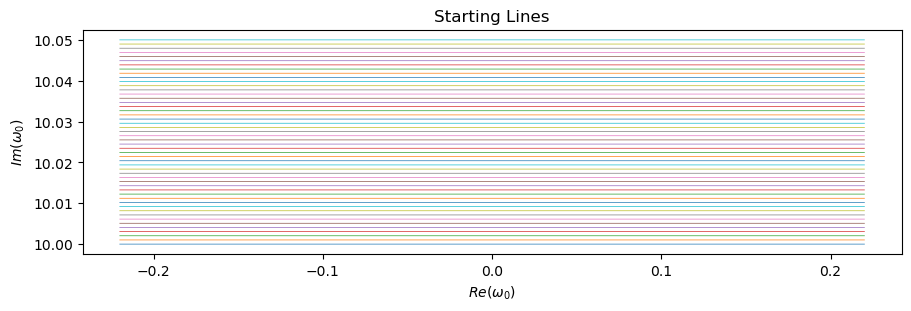

In [5]:
# starting grid
plot_w0_starting_lines(
    w0_real_arr,
    w0_imag_values,
    save_path=figure_dir / 'w0_starting_lines.pdf',
)


gamma = 1.088284 +/- 0.039632


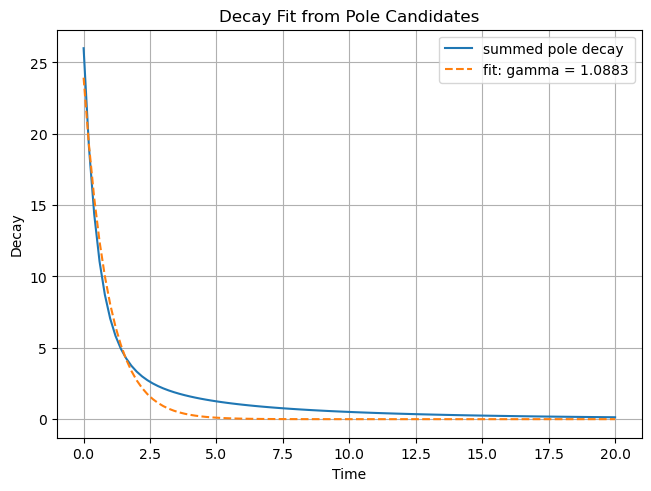

In [6]:
# decay fit for a = 1 using the same log|G| grid used by the sweep
decay_a = 1.0
decay_idx = int(np.flatnonzero(np.isclose(a_values, decay_a))[0])
decay_w0_arr = (
    w0_real_arr_by_a[decay_idx][None, :]
    + 1j * w0_imag_values[:, None]
).ravel()
gamma, gamma_err, n_poles, decay_log_abs_g, decay_pole_w = compute_sweep_scan_for_a(
    decay_a,
    decay_w0_arr,
    pole_config_for_a(decay_a),
    eps,
    m,
    n_step,
    denom_floor,
    g_abs_max,
    threads=total_cpus,
)
del decay_log_abs_g
gc.collect()
gamma, gamma_err, time, decay_curves, fit_curve = fit_gamma_from_poles(
    decay_pole_w
)
print(f'gamma = {gamma:.6f} +/- {gamma_err:.6f}')
plot_decay_fit(
    gamma,
    time,
    decay_curves,
    fit_curve,
    save_path=figure_dir / f'decay_fit_a_{format_a_for_filename(decay_a)}.pdf',
)


sweeping 52 a values with 8 processes x 4 numba threads
a = 0.417755: sweep found 34 pole candidates, gamma = 0.780384, threads = 4
a = 0.213878: sweep found 23 pole candidates, gamma = 0.446055, threads = 4
a = 0.1: sweep found 16 pole candidates, gamma = 0.321642, threads = 4
a = 0.01: sweep found 5 pole candidates, gamma = 0.175172, threads = 4
a = 0.82551: sweep found 32 pole candidates, gamma = 1.063932, threads = 4
a = 1: sweep found 34 pole candidates, gamma = 1.088284, threads = 4
a = 1.02939: sweep found 36 pole candidates, gamma = 1.113139, threads = 4
a = 0.621633: sweep found 28 pole candidates, gamma = 0.822207, threads = 4
a = 1.23327: sweep found 37 pole candidates, gamma = 1.322292, threads = 4
a = 1.43714: sweep found 42 pole candidates, gamma = 1.183575, threads = 4
a = 1.8449: sweep found 52 pole candidates, gamma = 1.344369, threads = 4
a = 1.64102: sweep found 46 pole candidates, gamma = 1.343959, threads = 4
a = 2.45653: sweep found 56 pole candidates, gamma = 1.6

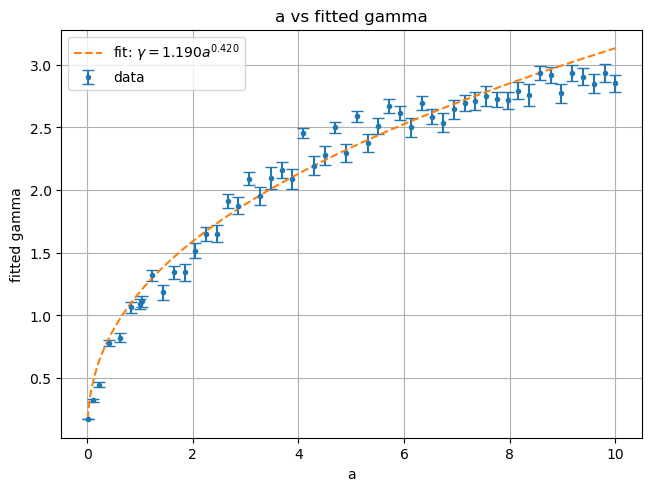

In [7]:
# sweep a and fit gamma = C * a^x
print(
    f'sweeping {len(a_values)} a values with '
    f'{sweep_n_jobs} processes x {sweep_num_threads_per_job} numba threads'
)
gamma_values, gamma_errors = sweep_gamma_vs_a(a_values)
C, C_err, x, x_err, fit_a, fit_gamma = fit_power_law(a_values, gamma_values, gamma_errors)

if np.isfinite(C) and np.isfinite(x):
    print(f'log-space power-law fit: gamma = {C:.6f} * a^{x:.6f}')
    print(f'C = {C:.6f} +/- {C_err:.6f}')
    print(f'x = {x:.6f}     +/- {x_err:.6f}')
else:
    print('not enough valid gamma values for power-law fit')

plot_a_gamma_fit(
    a_values,
    gamma_values,
    gamma_errors,
    C,
    x,
    fit_a,
    save_path=figure_dir / 'gamma_vs_a_power_law_fit.pdf',
)


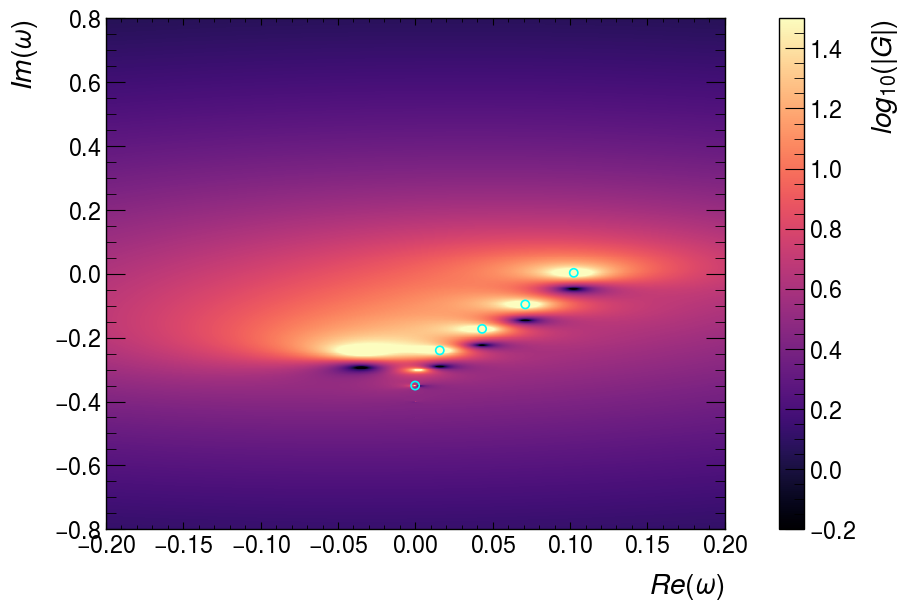

saved figures/sweep_pole_heatmap_a_0p01.pdf


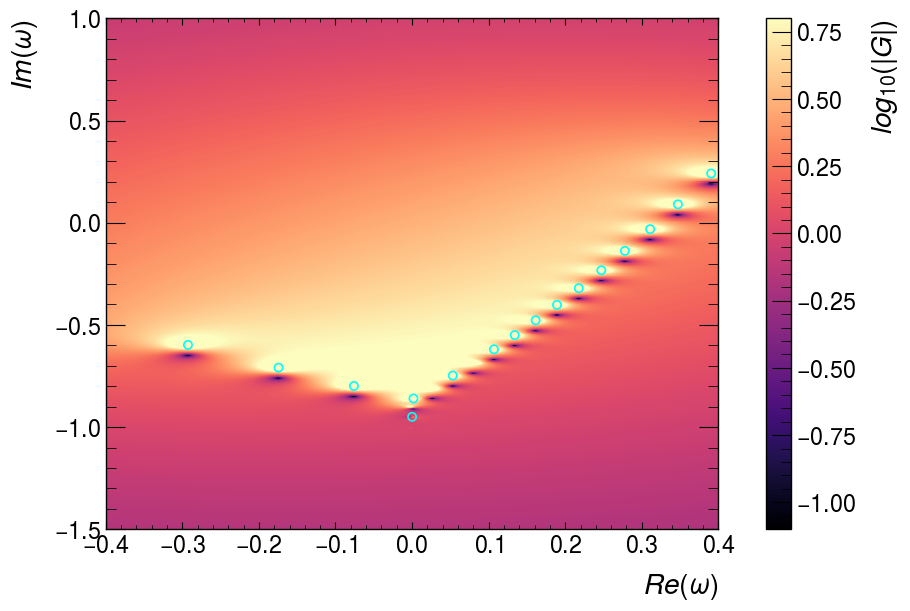

saved figures/sweep_pole_heatmap_a_0p1.pdf


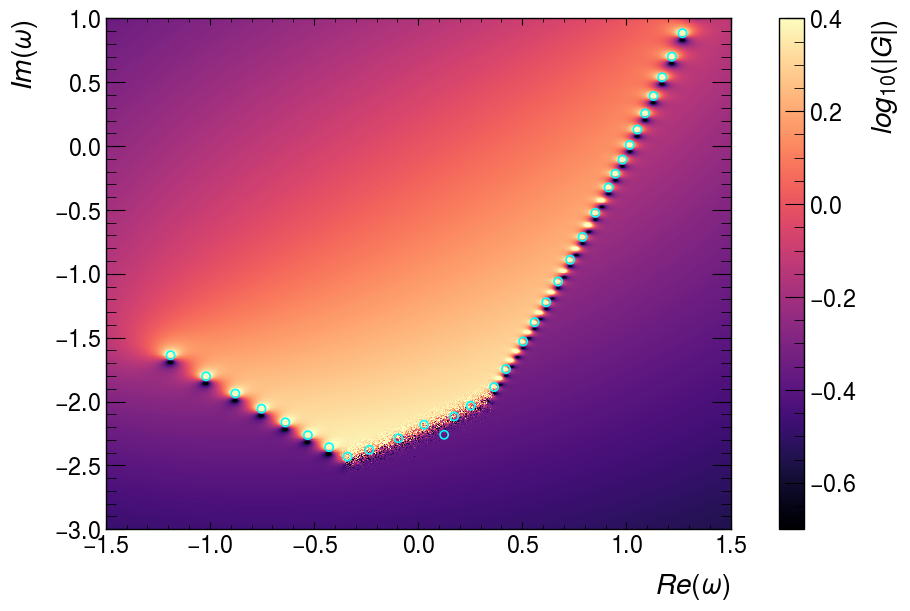

saved figures/sweep_pole_heatmap_a_1.pdf


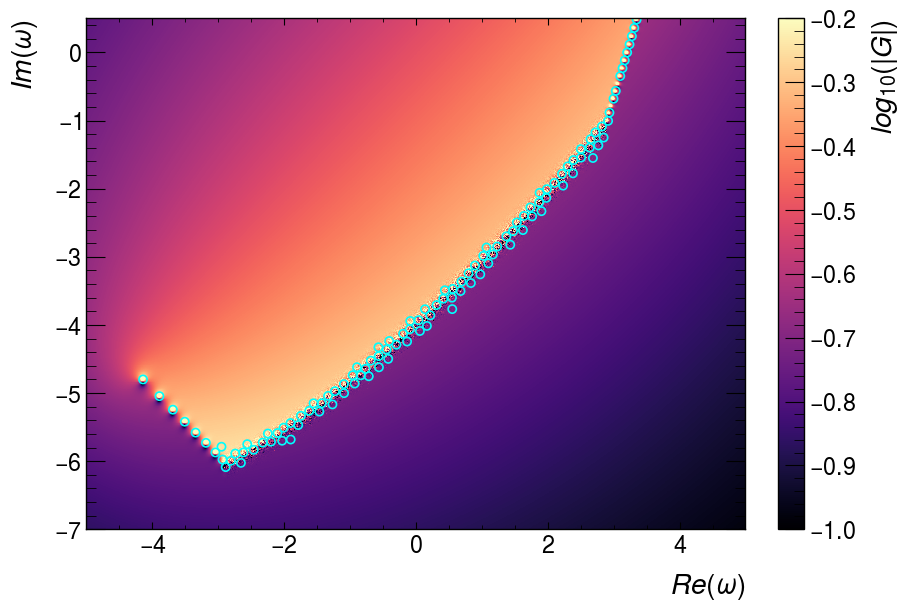

saved figures/sweep_pole_heatmap_a_10.pdf


In [8]:
import mplhep as hep
plt.style.use(hep.style.ATLAS) # larger and prettier plots for the heatmaps

plot_config_by_a = {
    0.01: {'xlim': (-0.2, 0.2), 'ylim': (-0.8, 0.8), 'log_vmin': -0.2, 'log_vmax': 1.5},
    0.1: {'xlim': (-0.4, 0.4), 'ylim': (-1.5, 1.0), 'log_vmin': -1.1, 'log_vmax': 0.8},
    1.0: {'xlim': (-1.5, 1.5), 'ylim': (-3.0, 1.0), 'log_vmin': -0.7, 'log_vmax': 0.4},
    10.0: {'xlim': (-5.0, 5.0), 'ylim': (-7.0, 0.5), 'log_vmin': -1.0, 'log_vmax': -0.2},
}

for heatmap_a in selected_a_values:
    plot_config = plot_config_by_a.get(heatmap_a, {})
    save_path = figure_dir / f'sweep_pole_heatmap_a_{format_a_for_filename(heatmap_a)}.pdf'
    plot_sweep_scan_from_npz(
        heatmap_a,
        **plot_config,
        save_path=save_path,
        show=True,
    )
    print(f'saved {save_path}')
